# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from section_loads import *

DATA = ROOT / "data"
OUT = ROOT / "outputs"
IMAGES = OUT / "images"
OUT.mkdir(exist_ok=True)

In [3]:
# Which end of each component to accumulate from. "low" starts at the lowest
# station coordinate, "high" at the highest.
# lh=high, rh=low
STATION_FROM = {"vehicle": "low",
                "fuselage": "low", 
                "wing lh": "high",
                "wing rh": "low",
                "tail lh": "high",
                "tail rh": "low",
                "tail lower": "low"}

In [4]:
VEHICLE = "vehicle"                    # its sections bin every body node
EXCLUDE_ITEMS = {"point masses"}       # node_ranges items kept out of sections
VEHICLE_CG = np.array([149, 0.0, 100])
INERTIA_SIGN = -1.0
ACCEL_TO_G = 1.0
ONLY_LOADCASES = ["100245", "10110002"]

# Body Load Processing

In [5]:
sections, node_ranges, load_cases, point_masses = read_tables(DATA)
df, load_cases = read_force_cards(DATA, load_cases, only=ONLY_LOADCASES)

display(load_cases)

,loadcase,configuration,nx,ny,nz,case_description,config
0,LC100245,FF,0.019043,0.0,4.500000,FF 1,FF
1,LC10110002,CC,0.000000,0.0,-4.433333,CC Navajo 1,CC


In [6]:
check_component_coverage(sections, node_ranges, VEHICLE, EXCLUDE_ITEMS)
check_configurations(sections, load_cases)
 
pd.concat([
    check_card_configurations(df, load_cases),
    check_sections_per_configuration(sections, node_ranges, load_cases,
                                     VEHICLE, EXCLUDE_ITEMS),
])

,loadcase,from_folder,from_csv,agree
0,LC10110002,CC,CC,True
1,LC100245,FF,FF,True


In [7]:
df = tag_components(df, node_ranges, EXCLUDE_ITEMS)
node_report(df)

,component,nodes,excluded,in_sections
0,fuselage,82345,0,82345
1,point masses,19,19,0
2,tail lh,2030,0,2030
3,tail lower,1163,0,1163
4,tail rh,2015,0,2015
5,wing lh,7060,0,7060
6,wing rh,7156,0,7156


In [8]:
pm_loads = point_mass_loads(point_masses, load_cases, INERTIA_SIGN, ACCEL_TO_G)
sec, bodies = run_sections(df, sections, load_cases, VEHICLE)
assignment_report(bodies, sections, VEHICLE)

,configuration,partition,component,sta_dir,sections,nodes,assigned,orphans,gaps
0,CC,component,fuselage,X,10,82345,82345,0,0
1,CC,component,tail lh,Y,4,2030,2030,0,0
2,CC,component,tail lower,Z,4,1163,1163,0,0
3,CC,component,tail rh,Y,4,2015,2015,0,0
4,CC,component,wing lh,X,6,6753,6753,0,0
5,CC,component,wing rh,X,6,6849,6849,0,0
6,CC,vehicle,vehicle,X,10,101155,101155,0,0
7,FF,component,fuselage,X,10,82345,82345,0,0
8,FF,component,tail lh,Y,4,2030,2030,0,0
9,FF,component,tail lower,Z,4,1163,1163,0,0


In [9]:
agree = check_partitions_agree(sec, VEHICLE_CG)
audit = force_audit(df, pm_loads, VEHICLE_CG, sec)
display(audit)

,loadcase,group,rows,Fx,Fy,Fz,Mx,My,Mz
0,LC100245,1 all card rows,101788,0.007807,0.003207,-0.003723,3.582542e-01,-1.835078e+02,287.810571
1,LC100245,2 held-out item rows,19,-1.246190,0.000000,-294.429700,-1.156559e+02,9.247214e+02,0.464153
2,LC100245,3 card rows in sections,101769,1.253997,0.003207,294.425977,1.160141e+02,-1.108229e+03,287.346418
3,LC100245,3a component sections,34,1.253997,0.003207,294.425977,1.160141e+02,-1.108229e+03,287.346418
4,LC100245,4 point mass loads,19,-36.128794,0.000000,-8537.467500,-1.150845e+06,-1.224300e+06,4870.139039
5,LC100245,5 TOTAL (3 + 4),0,-34.874798,0.003207,-8243.041523,-1.150729e+06,-1.225408e+06,5157.485456
6,LC10110002,1 all card rows,101174,0.484685,102.254560,-1651.628751,-3.870120e+02,2.647224e+03,230.176398
7,LC10110002,2 held-out item rows,19,0.000000,0.000000,-435.101100,-1.709121e+02,1.366465e+03,0.000000
8,LC10110002,3 card rows in sections,101155,0.484685,102.254560,-1216.527651,-2.160999e+02,1.280758e+03,230.176398
9,LC10110002,3a component sections,34,0.484685,102.254560,-1216.527651,-2.160999e+02,1.280758e+03,230.176398


In [10]:
cg_breakdown(sec, pm_loads, VEHICLE_CG)

,loadcase,partition,level,component,section_id,label,sta_lo,sta_hi,n_nodes,Fx,Fy,Fz,Mx,My,Mz
0,LC100245,component,section,fuselage,30000001,Nosecone,100.745,103.97,2123.0,22.566602,1.228247,-14.754814,1.372928e+00,-6.444240e+02,-53.067382
1,LC100245,component,section,fuselage,30000002,Fwd Body 1,103.970,113.97,7197.0,-4.538365,-6.188290,-25.774805,-1.132290e+00,-9.910705e+02,237.898890
2,LC100245,component,section,fuselage,30000003,Fwd Body 2,113.970,123.97,6377.0,-16.595902,3.005666,-55.063200,-7.829855e-01,-1.611174e+03,-93.132946
3,LC100245,component,section,fuselage,30000004,Mid Body 1,123.970,133.97,15185.0,-0.182723,-1.273900,-50.591907,-1.667173e+01,-1.042103e+03,30.883858
4,LC100245,component,section,fuselage,30000005,Mid Body 2,133.970,143.97,16327.0,-0.172903,-0.862213,-39.697750,-1.064931e+01,-4.070360e+02,6.192346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,LC10110002,vehicle,section,vehicle,9,Aft Body 2,173.970,183.97,7603.0,3.639230,18.377839,-129.597606,-2.339608e+01,4.037382e+03,600.005720
106,LC10110002,vehicle,section,vehicle,10,Aft Body 3,183.970,195.00,7209.0,-1.633672,29.691181,-197.458760,-1.744819e+02,7.496858e+03,1084.726921
107,LC10110002,vehicle,subtotal,vehicle,,vehicle total,NaN,NaN,101155.0,0.484685,102.254560,-1216.527651,-2.160999e+02,1.280758e+03,230.176398
108,LC10110002,vehicle,point masses,,,,NaN,NaN,NaN,0.000000,0.000000,8410.986499,1.133796e+06,1.209710e+06,0.000000


In [11]:
export_section_loads(sec, OUT / "section_loads.csv")
export_point_mass_loads(pm_loads, OUT / "point_mass_loads.csv")
pd.DataFrame({"file": sorted(p.name for p in OUT.glob("*.csv"))})

,file
0,point_mass_loads.csv
1,section_loads.csv


# Station Envelopes

In [12]:
diag = station_diagram(sec, direction=STATION_FROM)
station_drivers(diag)

,partition,component,configuration,quantity,axis,peak,station,loadcase
0,component,fuselage,ALL,Fx,normal,22.566602,103.970000,LC100245
1,component,fuselage,ALL,Fy,lateral 1,60.229174,190.000000,LC10110002
2,component,fuselage,ALL,Fz,lateral 2,-896.954628,190.000000,LC10110002
3,component,fuselage,ALL,Mx,normal,-69.729916,173.970000,LC10110002
4,component,fuselage,ALL,My,lateral 1,-43898.014483,190.000000,LC10110002
5,component,fuselage,ALL,Mz,lateral 2,-3755.847831,190.000000,LC10110002
6,component,tail lh,ALL,Fy,normal,-20.833630,-14.500000,LC10110002
7,component,tail lh,ALL,Fz,lateral 1,-74.242321,-14.500000,LC10110002
8,component,tail lh,ALL,Fx,lateral 2,-0.058935,-14.500000,LC100245
9,component,tail lh,ALL,My,normal,-25.593545,-7.200000,LC10110002


{('fuselage', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('tail lh', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('tail lower', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('tail rh', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('wing lh', 'CC'): <Figure size 1500x700 with 6 Axes>,
 ('wing lh', 'FF'): <Figure size 1500x700 with 6 Axes>,
 ('wing rh', 'CC'): <Figure size 1500x700 with 6 Axes>,
 ('wing rh', 'FF'): <Figure size 1500x700 with 6 Axes>}

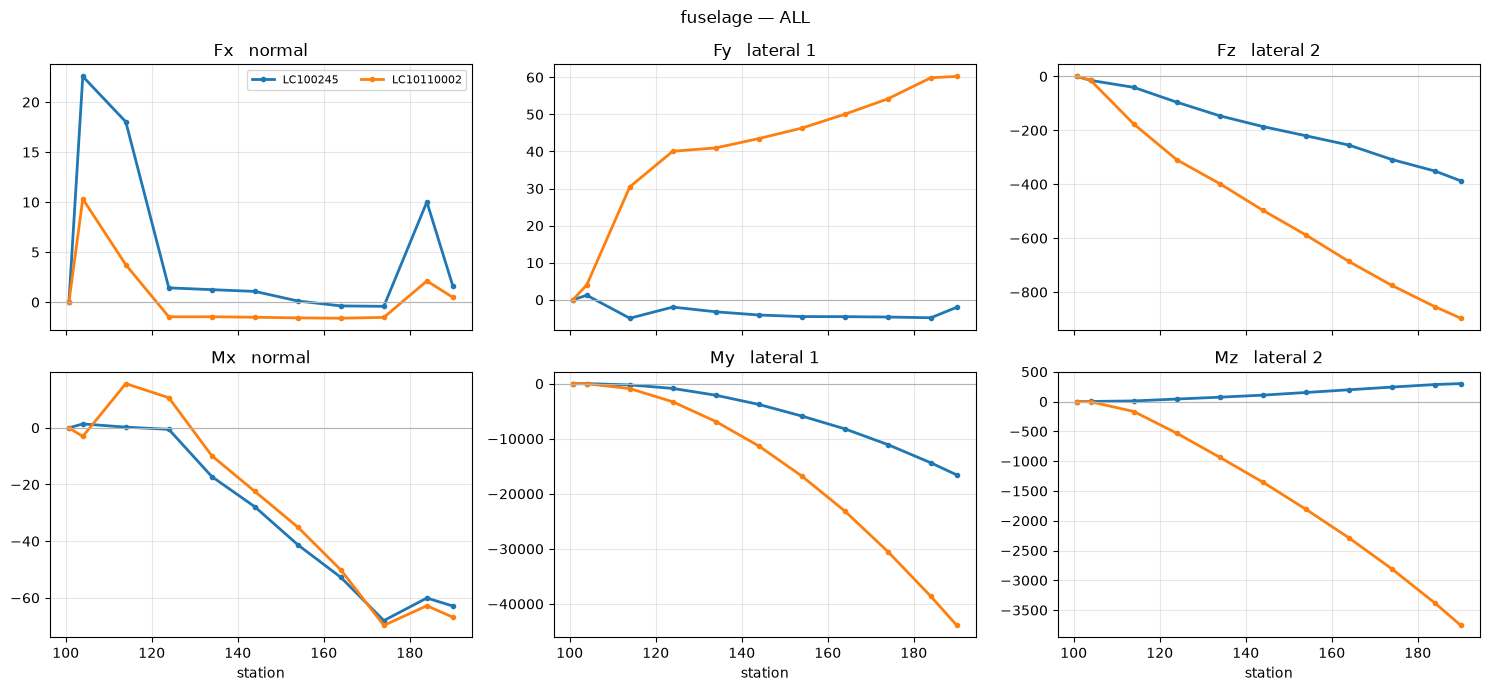

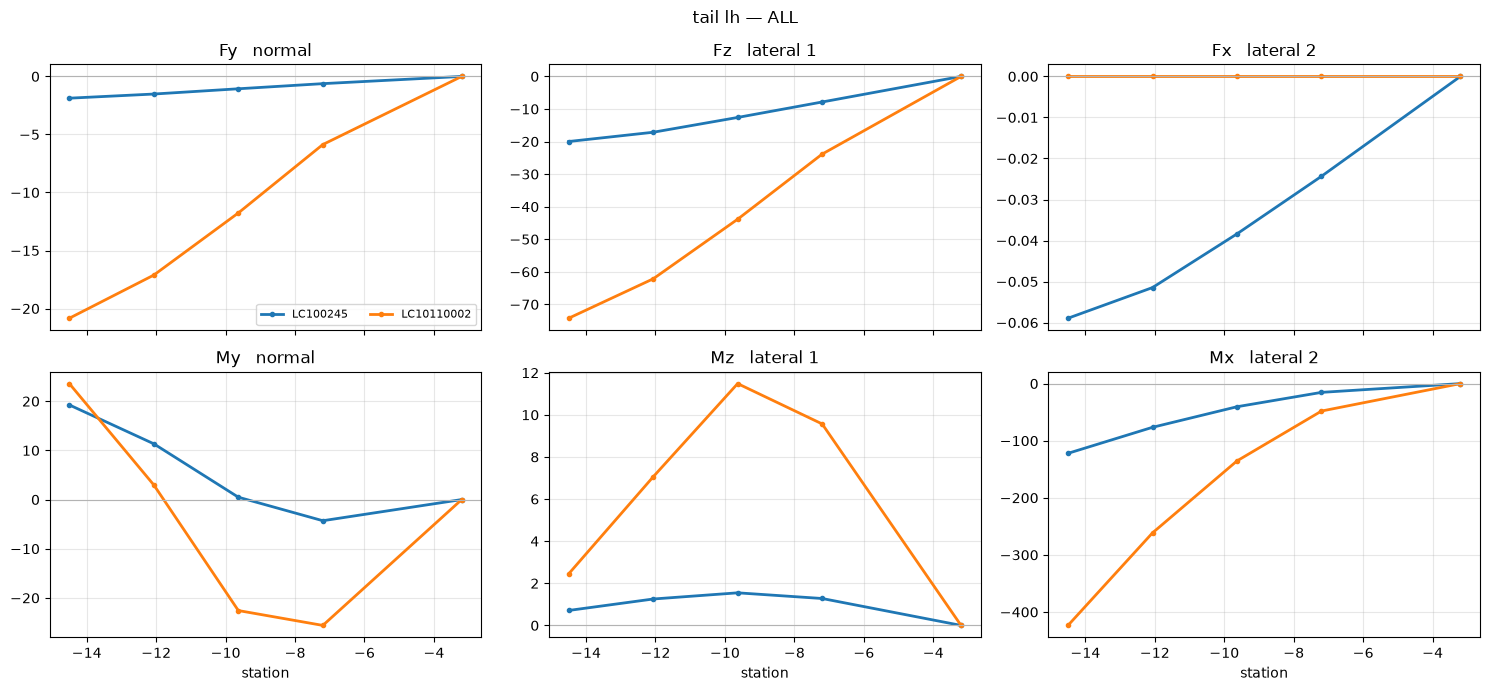

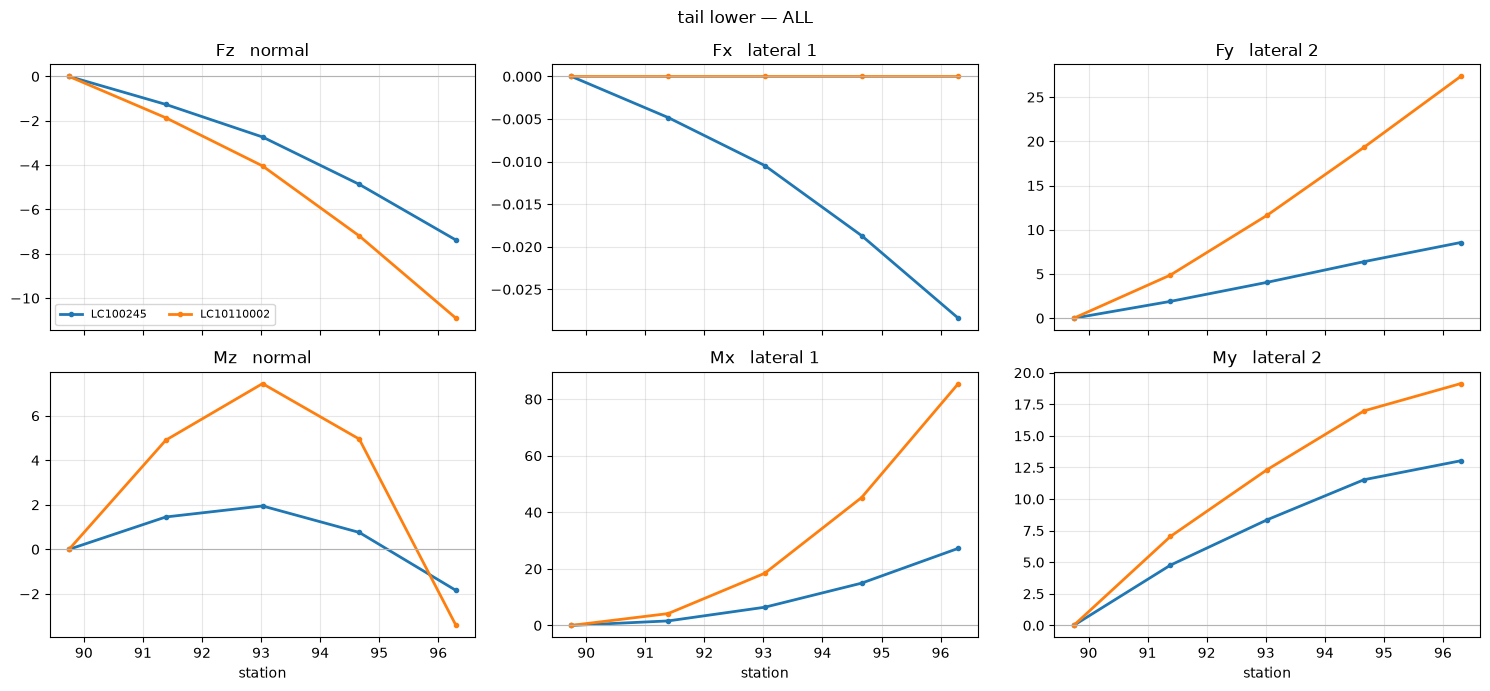

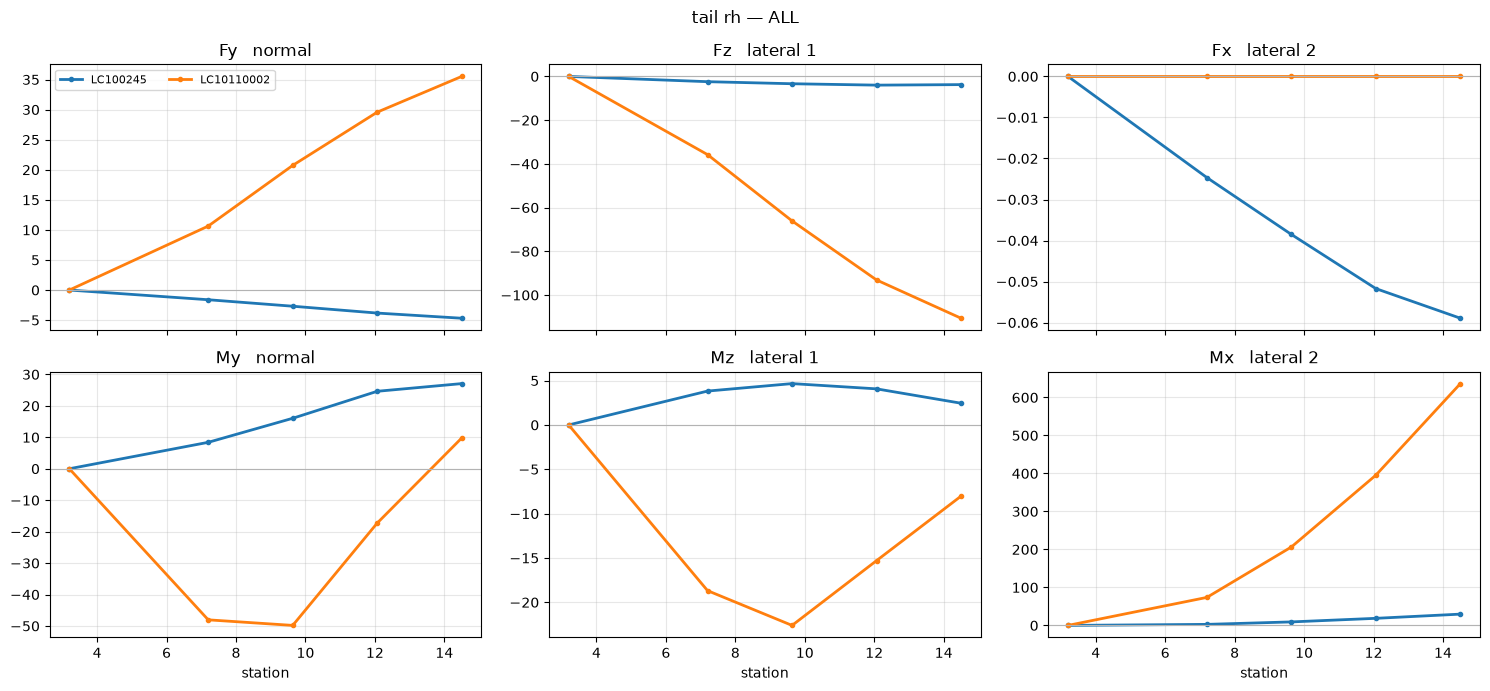

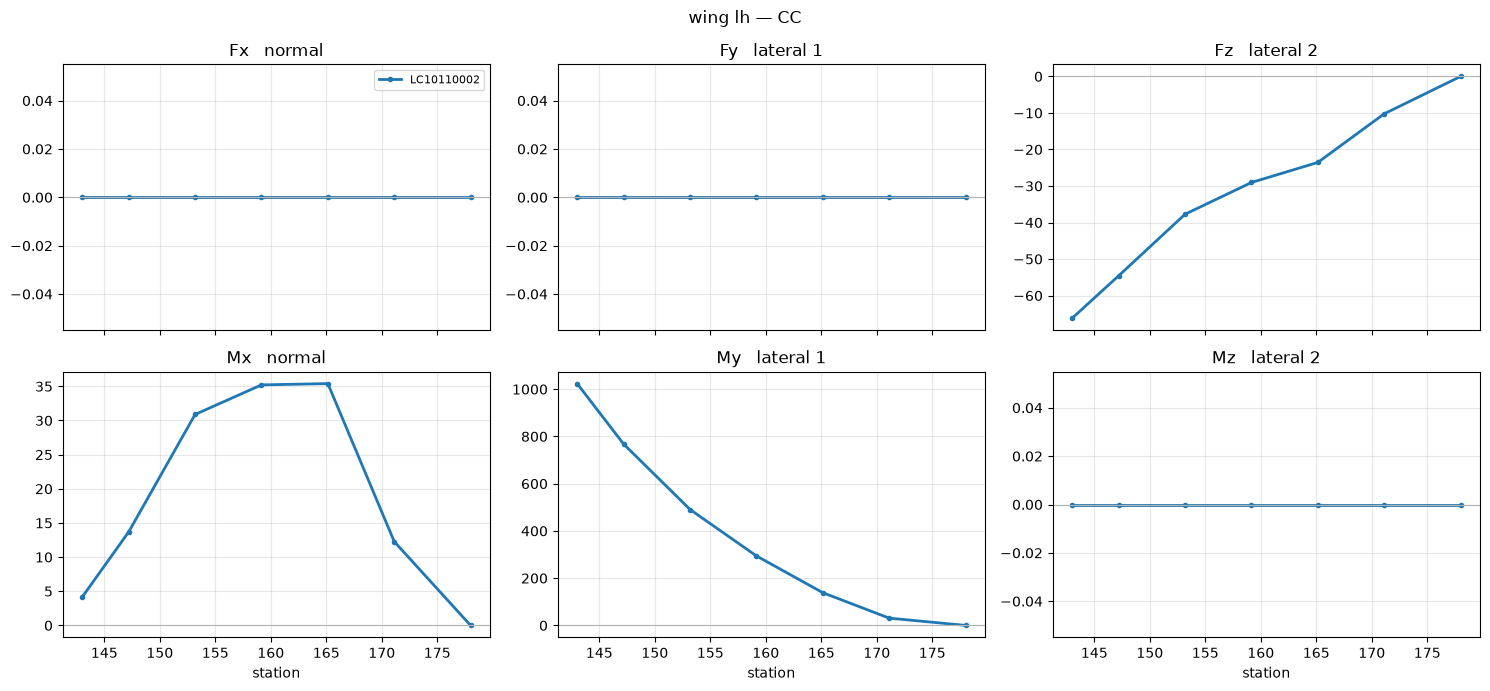

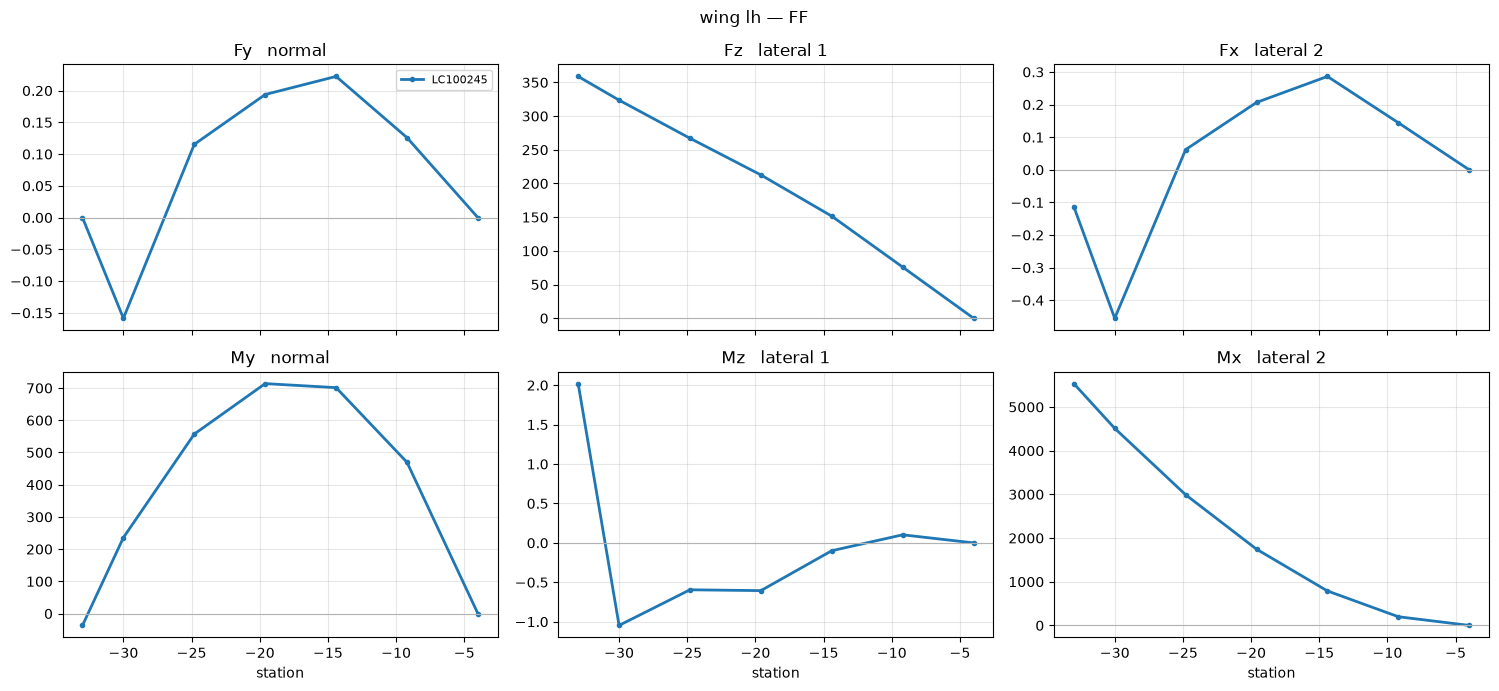

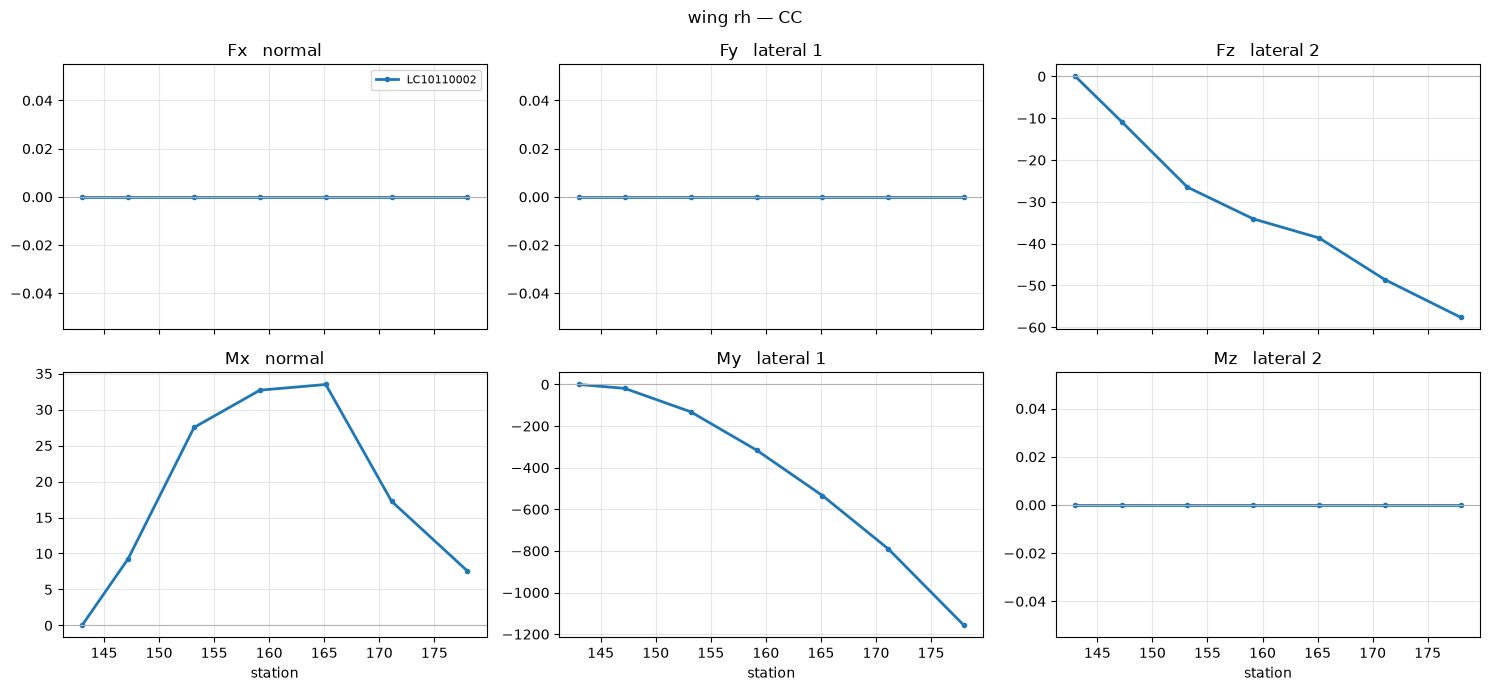

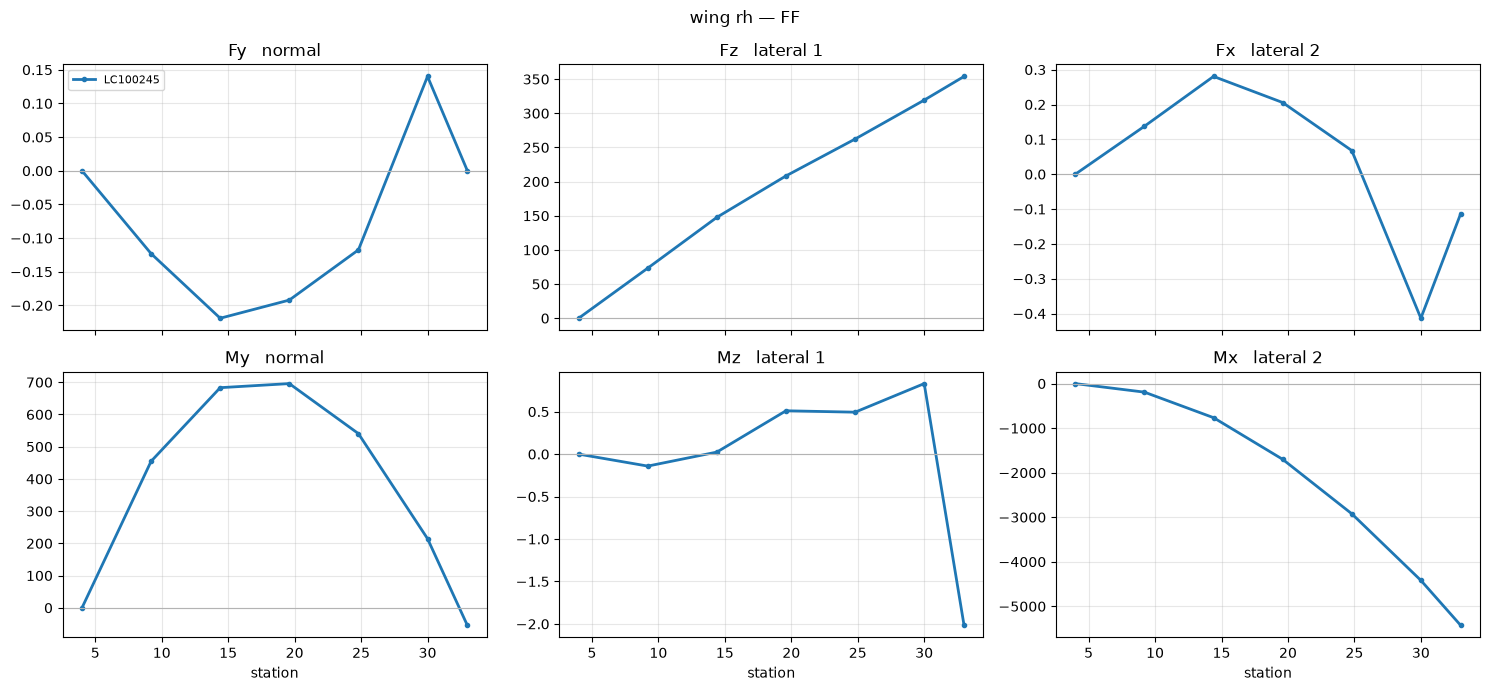

In [13]:
plot_all_station_diagrams(diag, out_dir=IMAGES)